# Altair Practice Lab

In this assignment we will be crafting a series of visualizations using
Altair to get practice working with real data in this context.

Your responses should be within the functions given,
using appropriate helper functions to help with clarity
and reduce redundancy.

## Rubric

The criteria to receive full credit on this assignment is a good-faith attempt at each portion.

A good-faith attempt should either:

- be fundamentally correct producing the expected output with minimal deviations,
- **OR** contain an explanation of what does not work and _details on what was tried_.

**For half credit, at least half of the assignment should have good-faith attempts.**

Your charts do not need to match the examples exactly!  They are helpful to get a sense of what you're after, but focus on the problem description and feel free to experiment as you see fit.

## Introducing the Dataset

In the data directory you'll find three files:

**legislators.csv** which consists of ~7400 records representing state legislators, it has the following fields:

- name
- given_name
- family_name
- party: As reported by the state.
- gender: Male / Female / Other\*
- jurisdiction: This field contains an identifier for the state or jurisdiction, see below for details.
- district: the name of the district represented
- type: upper | lower - The classification of the legislative. Most states have both, but DC and NE only have an upper chamber.

Note: Accurate data on gender is hard to come by in many states. There may be irregularities in this field. This is also why this field does not make further distinctions beyond Male/Female/Other.

**populations.csv** 

A CSV file with a row with each state's population.  

**actions.csv**

A CSV file with legislative actions for a few states across a range of years:

- description: action text as reported by state
- date: date of action recorded
- classification: not used for this assignment
- state: 2-letter state postal code (note: these are upper case, other files use lower case)
- session: an identifier representing which session the action comes from (not used)

In [11]:
# PUT YOUR IMPORTS HERE
from pathlib import Path

import pandas as pd

import altair as alt

data_dir = Path("data")

actions = pd.read_csv(data_dir / "actions_il-in-mi-wi_2021-2024.csv")
legislators = pd.read_csv(data_dir / "legislators.csv")
populations = pd.read_csv(data_dir / "populations.csv")

datasets = {
    "Actions": actions,
    "Legislators": legislators,
    "Populations": populations,
}


In [12]:
legislators.head()

,name,given_name,family_name,gender,party,jurisdiction,district,type
0,Robert White,Robert C.,White,Male,Independent,ocd-jurisdiction/country:us/district:dc/govern...,At-Large,legislature
1,Charles Allen,Charles,Allen,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 6,legislature
2,Vince Gray,Vincent Condol,Gray,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 7,legislature
3,Phil Mendelson,Philip Heath,Mendelson,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Chairman,legislature
4,Trayon White,Trayon,White,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 8,legislature


In [13]:
actions.head()

,description,date,classification,state,session
0,"Filed with the Clerk by Rep. Marcus C. Evans, Jr.",2021-02-10,['filing'],IL,102nd
1,Filed with Secretary,2021-08-26,['filing'],IL,102nd
2,Filed with Secretary by Sen. Jacqueline Y. Col...,2021-02-25,['filing'],IL,102nd
3,Filed with Secretary,2022-01-19,['filing'],IL,102nd
4,Filed with Secretary,2022-11-29,['filing'],IL,102nd


In [14]:
populations.head()

,state,pop_2020
0,al,5024294
1,ak,733374
2,az,7157902
3,ar,3011490
4,ca,39538212


## Part 1: Data Exploration

First, we'll build a few exploratory visualizations to get a sense of the data for this assignment.

### 1.0: Cleaning

As mentioned above, there is no 'state' field. Jurisdiction is in the format:

`ocd-jurisdiction/country:us/state:nc/government`

and for non-states:

- `ocd-jurisdiction/country:us/district:dc/government`
- `ocd-jurisdiction/country:us/territory:pr/government`

So for our purposes, we want to add a `state` column from the two letter code after either "state:", "district:", or "territory:".
(We will treat DC and PR as states.)

Complete the function `legislators_df` which should return the data from `legislators.csv` in a dataframe, with an additional `state` column.

In legislator dataset, there is a column called juriscition and inside is the state (2 letters)

In [15]:
# Extracts the two-letter state, district, or territory code from the jurisdiction 
# column and adds it to a new state column in a copy of the legislators DataFrame.

def legislators_df():
    df= legislators.copy()
    df["state"]= df["jurisdiction"].str.extract(r"(?:state|district|territory):([a-z]{2})/")
    return df

# render dataframe
legislators_df()

,name,given_name,family_name,gender,party,jurisdiction,district,type,state
0,Robert White,Robert C.,White,Male,Independent,ocd-jurisdiction/country:us/district:dc/govern...,At-Large,legislature,dc
1,Charles Allen,Charles,Allen,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 6,legislature,dc
2,Vince Gray,Vincent Condol,Gray,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 7,legislature,dc
3,Phil Mendelson,Philip Heath,Mendelson,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Chairman,legislature,dc
4,Trayon White,Trayon,White,Male,Democratic,ocd-jurisdiction/country:us/district:dc/govern...,Ward 8,legislature,dc
...,...,...,...,...,...,...,...,...,...
7430,Sol Higgins,Sol Yamiz,Higgins Cuadrado,Female,Partido Popular Democrático,ocd-jurisdiction/country:us/territory:pr/gover...,35,lower,pr
7431,Migdalia González,Migdalia I.,Gonzalez Arroyo,Female,Partido Popular Democrático,ocd-jurisdiction/country:us/territory:pr/gover...,4,upper,pr
7432,Keren Riquelme,Keren L.,Riquelme Cabrera,Female,Partido Nuevo Progresista,ocd-jurisdiction/country:us/territory:pr/gover...,At-Large,upper,pr
7433,Jocelyne Rodríguez Negrón,Jocelyne M.,Rodriguez Negron,Female,Partido Popular Democrático,ocd-jurisdiction/country:us/territory:pr/gover...,19,lower,pr


### 1.1: Initial Plot

First let's build a visualization of gender breakdowns in state legislatures.
Use the following:

- stacked bars per state
- each segment of stacked bar is gender

Your graph should somewhat resemble *imgs/ex1.1.png*.

In [16]:
def states_by_gender_initial(df):
    counts = (
        df.groupby(["state", "gender"]).size().reset_index(name="count")
    ) 
    
    return alt.Chart(counts).mark_bar().encode(
        x=(alt.X("state:N", title="State")),
        y=(alt.Y("count:Q", title="Number of Legislators")),
        color=alt.Color("gender:N")
    )

# render chart
states_by_gender_initial(legislators_df())


alt.Chart(...)

### 1.2: Improvements

While it is clear from the first chart that there are more elected officials that are men than women, it is hard to compare across states.

Make the following adjustments:

- Normalize the chart so that each bar is a percentage, allowing for direct comparison across states.
- Since this is US political data, the colors red and blue have a strong meaning, associated with the Republican and Democratic parties. Change the color scheme to avoid red and blue. (I chose #8624f5 for women and #1fc3aa for men based on this article: <https://blog.datawrapper.de/gendercolor/>)
- Two states are very close to 50%, add a line at 50% using a layered chart to make it easier to see if they exceed 50% or not.

Your graph should somewhat resemble *imgs/ex1.2.png*.

In [17]:
def states_by_gender_improved(df):
    # Reuse original graph and encode to adapt things 
    bars = states_by_gender_initial(df).encode(
        y=alt.Y(
            "count:Q",
            stack="normalize",
            title="Share of Legislators",
            axis=alt.Axis(format=".0%")
        ),
        color=alt.Color(
            "gender:N",
            scale=alt.Scale(
                domain=["Female", "Male", "Other"],
                range=["#8624f5", "#1fc3aa", "#999999"]
            )
        ),
        order=alt.Order("gender:N", sort="ascending")
    )

    line = alt.Chart().mark_rule(color="black").encode(
        y=alt.datum(0.5)
    )

    return bars + line

states_by_gender_improved(legislators_df())

alt.LayerChart(...)

## Part 2: Party Breakdown

We'll now take a look at party control. We can start with essentially the same chart.

### 2.0 - Party Control

Copy your code from 1.2 above & modify it to use party instead of gender.  Your graph will wind up with too many parties, see `imgs/ex2.0.png`.

In [18]:

# Same as before but group by party instead of gender
def party_control_raw(df):
    counts = (
        df.groupby(["state", "party"])
        .size()
        .reset_index(name="count")
    )

    bars = alt.Chart(counts).mark_bar().encode(
        x=alt.X("state:N", title="State"),
        y=alt.Y(
            "count:Q",
            stack="normalize",
            axis=alt.Axis(format=".0%"),
            title="Share of Legislators"
        ),
        color=alt.Color("party:N", title="Party")
    )

    line = alt.Chart().mark_rule(color="black").encode(
        y=alt.datum(0.5)
    )

    return bars + line


party_control_raw(legislators_df())

alt.LayerChart(...)

### 2.1 - Cleaning Data

The above graph still has some shortcomings:

- Most states have an upper and lower chamber, and party control may vary between them. We'll need to make two bars per state (which we'll tackle in 2.2).
- Also, there are too many variations of party as you can see here:

Let's transform the data again, adding a new column "party_code" with the following rules:

- if the word 'Democratic' appears, set party_code to 'D'
- if the word 'Republican' appears, set the party_code to 'R'
- otherwise, set the party_code to 'O'

Party data in NE, DC, and PR does not work with this scheme.
For simplicity, we will exclude them from our analysis.

For this portion, implement `clean_party_df` which should return a modified legislators DataFrame with the `party_code` column, and the rows for states 'DC', 'NE' and 'PR' dropped.

In [19]:
def clean_party_df():
    # Start with the DataFrame from part 1 & return transformed copy
    df = legislators_df()
    # Identify excluded "states" and remove them from the DataFrame
    df =df.loc[~df["state"].isin(["dc","ne","pr"])].copy()
    
    df["party_code"]= "O"
    
    # If party contains rep/dem then change value to R/D
    df.loc[
        df["party"].str.contains("Republican",na=False),
        "party_code"
    ] ="R"
    df.loc[
        df["party"].str.contains("Democratic",na=False),
        "party_code"
    ] ="D"

    return df

clean_party_df()

,name,given_name,family_name,gender,party,jurisdiction,district,type,state,party_code
13,Kevin McCabe,Kevin J.,McCabe,Male,Republican,ocd-jurisdiction/country:us/state:ak/government,30,lower,ak,R
14,C.J. McCormick,Conrad J.,McCormick,Male,Democratic,ocd-jurisdiction/country:us/state:ak/government,38,lower,ak,D
15,Bill Wielechowski,Bill P.,Wielechowski,Male,Democratic,ocd-jurisdiction/country:us/state:ak/government,K,upper,ak,D
16,Justin Ruffridge,Justin,Ruffridge,Male,Republican,ocd-jurisdiction/country:us/state:ak/government,7,lower,ak,R
17,Will Stapp,Will,Stapp,Male,Republican,ocd-jurisdiction/country:us/state:ak/government,32,lower,ak,R
...,...,...,...,...,...,...,...,...,...,...
7353,Karlee Provenza,Karlee R.,Provenza,Female,Democratic,ocd-jurisdiction/country:us/state:wy/government,45,lower,wy,D
7354,Affie Ellis,Affie Burnside,Ellis,Female,Republican,ocd-jurisdiction/country:us/state:wy/government,8,upper,wy,R
7355,Abby Angelos,Abby,Angelos,Female,Republican,ocd-jurisdiction/country:us/state:wy/government,3,lower,wy,R
7356,Pepper Ottman,Pepper L.,Ottman,Female,Republican,ocd-jurisdiction/country:us/state:wy/government,34,lower,wy,R


### 2.2 - Faceted Plot

Add a function `party_control_by_chamber` that contains the following elements:

- One bar per state, **along the Y axis**.
- Each bar should consist of a stack: a blue portion, a green portion, and a red portion, corresponding to the D, O, and R `party_code` respectively.
- A vertical line at the 50% mark, indicating (likely) party control.
- Finally, facet the chart on `type` so that you get a set of bars for the lower and upper chambers.

See `imgs/ex2.2.png` for an example.

In [20]:
def party_control_by_chamber(df):
    counts = (
        df.groupby(["state", "type", "party_code"])
        .size()
        .reset_index(name="count")
    )
    base = alt.Chart(counts)

    bars = base.mark_bar().encode(
        y=alt.Y("state:N", title="State"),
        x=alt.X(
            "count:Q",
            stack="normalize",
            axis=alt.Axis(format=".0%"),
            title="Share of Legislators"
        ),
        color=alt.Color(
            "party_code:N",
            title="Party",
            scale=alt.Scale(
                domain=["D", "O", "R"],
                range=["blue", "green", "red"]
            )
        ),
        order=alt.Order("party_code:N", sort="ascending")
    )

    line = base.mark_rule(color="black").encode(
        x=alt.datum(0.5)
    )

    return (bars + line).properties(
        width=350,
        height=700
    ).facet(
        column=alt.Column("type:N", title="Chamber")
    )


party_control_by_chamber(clean_party_df())

alt.FacetChart(...)

## Part 3: Comparing by Population

For part three, we are interested in the relationship of various properties of legislatures to the total population of the state.

To do this, we'll need to create a combined DataFrame that mixes in data from `populations.csv`.

### 3.0 - Create Combined DataFrame

Write the function `population_combined_df`, which should return a DataFrame with the columns:

- state: abbreviation of state
- upper: total seats in upper chamber
- lower: total seats in lower chamber
- pop_2020: the 2020 population, obtained from merging with `population.csv`

**Data Note:** These numbers are based on the non-vacant seats as-of a particular day in September 2024. Vacancies will cause the counts to be off by a bit, but the general size of the legislature should be roughly the same.

In [ ]:
# Returns a DataFrame with each state's upper and lower chamber seat counts and 2020 population.
def population_combined_df():

    seats = (
        legislators_df()
        .groupby(["state", "type"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    combined = seats.merge(populations, on="state", how="left")

    return combined[["state", "upper", "lower", "pop_2020"]]

population_combined_df()


,state,upper,lower,pop_2020
0,ak,20,40,733374
1,al,35,104,5024294
2,ar,35,98,3011490
3,az,30,59,7157902
4,ca,40,79,39538212
5,co,35,65,5773707
6,ct,36,151,3605912
7,dc,0,0,689548
8,de,21,41,989946
9,fl,40,119,21538216


### 3.1 - Create Population vs. Seats Scatterplot

Create a new plot with two layers:

- Population on the X axis
- Number of seats on the Y axis
- Upper chamber points should be purple and use the 'triangle-up' shape.
- Lower chamber points should be orange and use the 'triangle-down' shape.
- Make a customization or two to your chart's default labels and axes, whatever you feel is appropriate.

Hint: You can layer two charts for this.

In [ ]:
def scatter_pop_size():
    
    df = population_combined_df()

    #2020 population in x axis and and seats on y axis
    chart = alt.Chart(df).encode(
        x=alt.X("pop_2020:Q", title="2020 Population")
        )
    # Create points upper chamber
    upper = chart.mark_point(
        color="purple",
        shape="triangle-up",
        filled=True,
        size=100
    ).encode(
        y=alt.Y("upper:Q", title="Number of Seats"),
        tooltip=[
            alt.Tooltip("state:N", title="State"),
            alt.Tooltip("pop_2020:Q", title="Population", format=","),
            alt.Tooltip("upper:Q", title="Upper Chamber Seats")
        ]
    )
    # Create points lower chamber
    lower = chart.mark_point(
        color="orange",
        shape="triangle-down",
        filled=True,
        size=100
    ).encode(
        y=alt.Y("lower:Q", title="Number of Seats"),
        tooltip=[
            alt.Tooltip("state:N", title="State"),
            alt.Tooltip("pop_2020:Q", title="Population", format=","),
            alt.Tooltip("lower:Q", title="Lower Chamber Seats")
        ]
    )

    return (upper + lower).properties(
        width=600,
        height=350,
        title="Population vs. Legislature Size"
    )


scatter_pop_size()


alt.LayerChart(...)

### 3.2 - Regressions

Add two more layers, a purple & orange regression line for each chamber.  See `imgs/ex3.2.png`

Hint: See `transform_regression`.

In [51]:
def scatter_pop_size_regression():
    df = population_combined_df()

    points = scatter_pop_size()

    base = alt.Chart(df).encode(
        x=alt.X("pop_2020:Q", title="2020 Population")
    )

    upper_line = base.transform_regression(
        "pop_2020", "upper", method="linear"
    ).mark_line(color="purple").encode(
        y=alt.Y("upper:Q", title="Number of Seats")
    )

    lower_line = base.transform_regression(
        "pop_2020", "lower", method="linear"
    ).mark_line(color="orange").encode(
        y=alt.Y("lower:Q", title="Number of Seats")
    )

    return (points + upper_line + lower_line).properties(
        width=600,
        height=350,
        title="Population vs. Legislature Size"
    )


scatter_pop_size_regression()

alt.LayerChart(...)

## Part 4: Actions Heatmap

The file `actions_il-in-mi-wi_2021-2024.csv` contains nearly half a million records, representing every official action taken on a piece of legislation in these four midwestern states over the past two sessions.

Legislatures work quite differently, some meet all year, while others meet for very short periods.
By creating a heatmap of what days actions take place, we can get a sense of how different states compare.

### 4.0 - Load Actions

Complete `actions_df`, which should load the data from `actions_il-in-mi-wi_2021-2024.csv`.

Tips: 
- Make sure that the `date` column is loaded as a date type!
- Dates are in YYYY-MM-DD format, though some also have additional characters for time, which you will want to ignore.

In [ ]:
def actions_df():
    df_actions = actions.copy()
    # First 10 characters of the date string and convert to datetime
    df_actions["date"] = pd.to_datetime(df_actions["date"].str[:10], format="%Y-%m-%d")
    return df_actions

actions_df()

,description,date,classification,state,session
0,"Filed with the Clerk by Rep. Marcus C. Evans, Jr.",2021-02-10,['filing'],IL,102nd
1,Filed with Secretary,2021-08-26,['filing'],IL,102nd
2,Filed with Secretary by Sen. Jacqueline Y. Col...,2021-02-25,['filing'],IL,102nd
3,Filed with Secretary,2022-01-19,['filing'],IL,102nd
4,Filed with Secretary,2022-11-29,['filing'],IL,102nd
...,...,...,...,...,...
456400,Partial veto failed to pass notwithstanding th...,2022-05-17,[],WI,2021
456401,Fiscal estimate received,2021-02-08,['receipt'],WI,2021
456402,Fiscal estimate received,2021-02-10,['receipt'],WI,2021
456403,Placed on calendar 5-17-2022 pursuant to Joint...,2022-05-17,[],WI,2021


### 4.1 - Actions Heatmap

Generate a heatmap (using `mark_rect`) with:

- a row per state
- each row consists of shaded marks with shading based on the total action count for a given week

Tip: Use the 'yearweek(date)' aggregation for the X channel.

See `imgs/ex4.1.png`.

In [ ]:
def actions_heatmap_scaled(df):
    weekly_counts = (
        # Assigns starting week to each date
        df.assign(date=df["date"].dt.to_period("W-SUN").dt.start_time)
        .groupby(["state", "date"])
        .size()
        .reset_index(name="action_count")
    )

    return alt.Chart(weekly_counts).mark_rect().encode(
        x=alt.X(
    "yearmonthdate(date):O",
    title="date (year-week)",
    axis=alt.Axis(
        format="W%V %G",
        labelAngle=-90,
        labelOverlap=True
    )
),
        y=alt.Y("state:N", title="State"),
        color=alt.Color(
            "action_count:Q",
            title="Weekly Actions",
            scale=alt.Scale(scheme="blues")
        ),
        tooltip=[
            alt.Tooltip("state:N", title="State"),
            alt.Tooltip("date:T", title="Week Starting", format="%Y-%m-%d"),
            alt.Tooltip("action_count:Q", title="Actions", format=",")
        ]
    ).properties(
        width=800,
        height=180,
        title="Weekly Legislative Actions by State"
    )


actions_heatmap_scaled(actions_df())

alt.Chart(...)

### 4.2 - Excluding IL Outliers

Illinois clearly dominates the above graph, below modify two calls to `actions_heatmap` with a modified dataframe that excludes IL, and a modified dataframe that only includes IL.

(Note how by using functions in our dataframe we can more easily reuse portions by making small adjustments to the data.)

See `ex4.2a.png` and `ex4.2b.png`

In [61]:
# MODIFY THIS LINE (exclude IL)
actions_heatmap_scaled(actions_df().query("state != 'IL'"))

alt.Chart(...)

In [62]:
# MODIFY THIS LINE (only IL)
actions_heatmap_scaled(actions_df().query("state == 'IL'"))

alt.Chart(...)

#### 4.3 - Cumulative Line Chart

Another way to view this data would be with a cumulative line chart.

Create a chart with:

- days on the X axis
- cumulative actions to date on the Y axis
- one line per state

Hint: To do this you will need to look at the `transform_window` function.

See `ex4.3.png` for an example.

In [63]:
def actions_cumulative(df):
    daily_counts = (
        df.groupby(["state", "date"])
        .size()
        .reset_index(name="action_count")
    )

    return alt.Chart(daily_counts).transform_window(
        cumulative_actions="sum(action_count)",
        sort=[alt.SortField("date", order="ascending")],
        groupby=["state"],
        frame=[None, 0]
    ).mark_line().encode(
        x=alt.X(
            "date:T",
            title="Date",
            axis=alt.Axis(format="%b %Y")
        ),
        y=alt.Y(
            "cumulative_actions:Q",
            title="Cumulative Actions",
            axis=alt.Axis(format=",")
        ),
        color=alt.Color("state:N", title="State"),
        tooltip=[
            alt.Tooltip("state:N", title="State"),
            alt.Tooltip("date:T", title="Date", format="%Y-%m-%d"),
            alt.Tooltip(
                "cumulative_actions:Q",
                title="Cumulative Actions",
                format=","
            )
        ]
    ).properties(
        width=800,
        height=350,
        title="Cumulative Legislative Actions by State"
    )


actions_cumulative(actions_df())

alt.Chart(...)

## Part 5. Replicating a Chart

Find a chart (perhaps the one you're using for your first Analysis post!) and do your best to replicate it with Altair. Since you likely won't have access to the raw data-- start by mocking up a dataset that is similar enough to what your chart uses, don't worry about exact values, just that the correct attributes are present with some variation.

Your replicated chart should use similar colors, labels, etc. to the one that you chose to reproduce. Again, we aren't looking for a pixel-perfect replica, but something that pushes you to explore parts of Altair's documentation/features that you didn't use above.


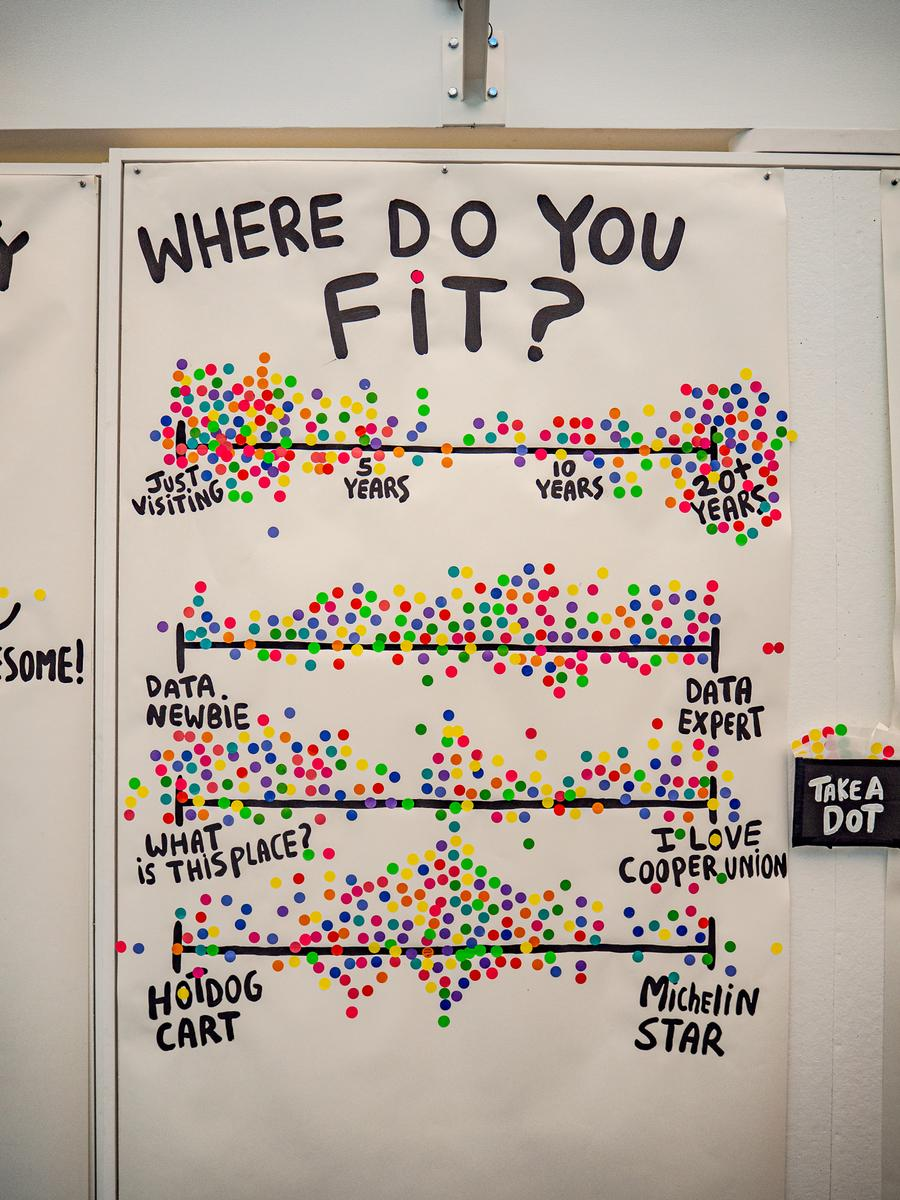

I will try to recrate this scatter plots with false data.

In [64]:
import random

rng = random.Random(42)

responses = pd.DataFrame({
    question: [round(rng.uniform(0, 10), 2) for respondent in range(100)]
    for question in [
        "time_in_city",
        "data_experience",
        "cooper_union_familiarity",
        "food_preference"
    ]
})

responses.head()

,time_in_city,data_experience,cooper_union_familiarity,food_preference
0,6.39,0.11,9.69,9.04
1,0.25,7.21,9.26,5.46
2,2.75,6.82,8.49,8.35
3,2.23,5.37,1.66,5.83
4,7.36,2.67,4.86,1.48


In [ ]:
def where_do_you_fit(responses):
    rng = random.Random(7)
    palette = [
        "#ec1852", "#f28e2b", "#f2d600",
        "#23c83a", "#12b5b0", "#3545a3", "#8854bd"
    ]

    questions = [
        ("time_in_city", "Time in the City",
         "Just visiting", "20+ years"),
        ("data_experience", "Data Experience",
         "Data newbie", "Data expert"),
        ("cooper_union_familiarity", "Cooper Union",
         "What is this place?", "I love Cooper Union"),
        ("food_preference", "Food Preference",
         "Hotdog cart", "Michelin star")
    ]

    charts = []
    # Each loop brings the four elements needed for each graph 
    for column, title, left_label, right_label in questions:
        plot_df = responses[[column]].copy()
        plot_df["jitter"] = [
            rng.uniform(-0.6, 0.6) for respondent in range(len(plot_df))
        ]
        plot_df["dot_color"] = [
            rng.choice(palette) for respondent in range(len(plot_df))
        ]

        baseline = alt.Chart(
            pd.DataFrame({"height": [0]})
        ).mark_rule(color="black", strokeWidth=2).encode(
            y=alt.Y("height:Q", axis=None)
        )

        points = alt.Chart(plot_df).mark_circle(
            size=65, opacity=0.9
        ).encode(
            x=alt.X(
                f"{column}:Q",
                title=None,
                scale=alt.Scale(domain=[0, 10], nice=False),
                axis=alt.Axis(
                    values=[0, 10],
                    labelExpr=(
                        f"datum.value === 0 ? '{left_label}' : '{right_label}'"
                    ),
                    labelAngle=0,
                    labelLimit=220,
                    grid=False,
                    domain=False,
                    ticks=False
                )
            ),
            y=alt.Y(
                "jitter:Q",
                title=None,
                axis=None,
                scale=alt.Scale(domain=[-1, 1])
            ),
            color=alt.Color("dot_color:N", scale=None, legend=None),
            tooltip=[alt.Tooltip(f"{column}:Q", title="Score", format=".2f")]
        )

        charts.append(
            (baseline + points).properties(
                width=600, height=110, title=title
            )
        )
    # vconcat to have 4 graphs vertically set
    return alt.vconcat(*charts, spacing=25).properties(
        title="Where Do You Fit?"
    ).configure_view(stroke=None)


where_do_you_fit(responses)

alt.VConcatChart(...)